# Генеративные модели

## Теоретическая часть

### Автоэнкодер (AE)

Автоэнкодер — это нейросеть, которая принимает на вход объект (например, изображение),
сжимает его в латентный вектор фиксированной размерности, а затем восстанавливает обратно.

Состоит из двух частей:

- **Энкодер** отображает входной вектор в латентное представление меньшей размерности.
- **Декодер** восстанавливает объект из латентного вектора.

Модель обучается минимизировать ошибку реконструкции (насколько сильно восстановленное изображение
отличается от исходного). Это делает автоэнкодер хорошим инструментом для сжатия, денойзинга
и выделения признаков, но он не задает явную вероятностную модель данных.

### Вариационный автоэнкодер (VAE)

Вариационный автоэнкодер накладывает на латентное пространство вероятностную структуру.
Вместо одного латентного вектора для каждого объекта он учит распределение в латентном пространстве
(обычно многомерное нормальное с параметрами среднее и дисперсия).

Обучение осуществляется по нижней оценке правдоподобия (ELBO), которая одновременно:

- поощряет хорошую реконструкцию объектов;
- прижимает распределение скрытых переменных к простому априорному распределению.

Благодаря этому VAE умеет как реконструировать данные, так и генерировать новые правдоподобные
примеры, отбирая точки напрямую из латентного распределения.

### Экспериментальная схема

- мы используем один и тот же датасет изображений;
- обучаем на нем простой автоэнкодер;
- обучаем на нем вариационный автоэнкодер с той же архитектурой энкодера и декодера;
- сравниваем качество реконструкции, структуру латентного пространства и сгенерированные семплы.

Логика: Теория → Гипотеза → Эксперимент → Интерпретация.


## Настройка окружения

In [1]:
# Импорты
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Фиксация генераторов случайных чисел
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")


Используемое устройство: cpu


## Подготовка данных

В качестве базовой задачи будем использовать простой датасет изображений цифр (MNIST).

Что сделаем:

- загрузим обучающую и тестовую выборки;
- нормализуем изображения в диапазон от 0 до 1;
- подготовим функции визуализации батча и реконструкций.


In [2]:
# Загрузка датасета MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")


Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


In [3]:
import torchvision  # импортируем здесь для функций визуализации

заметка: поменяла местами импорт и определение show_images

In [4]:
# Вспомогательная функция для визуализации батча изображений

def show_images(images, title="Примеры изображений", nrow=8):
    images = images.detach().cpu()
    grid = torch.clone(images[: nrow * nrow])
    fig, ax = plt.subplots(figsize=(nrow, nrow))
    grid = torchvision.utils.make_grid(grid, nrow=nrow, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()


---

## Задача 1. Загрузка и визуализация данных

### Постановка задачи

Загрузить обучающую выборку изображений цифр, посмотреть на форму тензоров
и визуализировать несколько примеров.


Форма батча изображений: torch.Size([128, 1, 28, 28])
Форма батча меток: torch.Size([128])


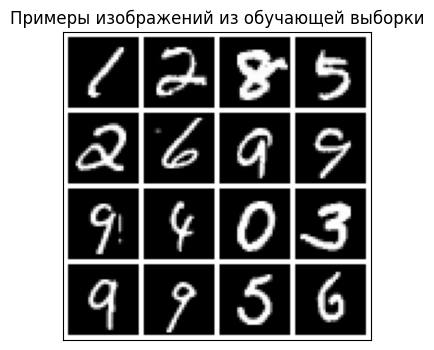

In [5]:
# Задача 1. Загрузка и визуализация данных

images, labels = next(iter(train_loader))

print("Форма батча изображений:", images.shape)
print("Форма батча меток:", labels.shape)

show_images(images[:16], title="Примеры изображений из обучающей выборки", nrow=4)


**Интерпретация:**
Данные загружены. Один батч содержит 128 изображений формы `1 × 28 × 28`, где `1` — число каналов, а `28 × 28` — размер изображения.

Форма меток `([128])` - каждому изображению соответствует одна целевая цифра.

## Задача 2. Реализация и обучение простого автоэнкодера

### Постановка задачи

Реализовать простой полносвязный автоэнкодер для изображений цифр:

- энкодер: несколько линейных слоев, сжимающих изображение в латентный вектор фиксированной размерности;
- декодер: несколько линейных слоев, восстанавливающих изображение из латентного вектора.

Обучить автоэнкодер на обучающей выборке и визуально оценить качество реконструкций.


Эпоха 1/5, loss = 0.0509
Эпоха 2/5, loss = 0.0243
Эпоха 3/5, loss = 0.0187
Эпоха 4/5, loss = 0.0155
Эпоха 5/5, loss = 0.0133


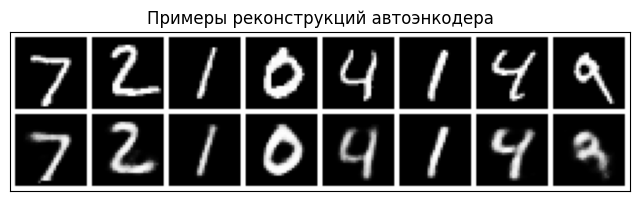

In [6]:
# Задача 2. Реализация и обучение простого автоэнкодера

class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # Энкодер: 784 -> 256 -> 128 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # Декодер: latent_dim -> 128 -> 256 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [batch, 1, 28, 28]
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

# устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleAutoencoder(latent_dim=32).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        reconstructions = model(images)
        loss = criterion(reconstructions, images)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Эпоха {epoch + 1}/{num_epochs}, loss = {epoch_loss:.4f}")

# визуализация реконструкций
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)

    reconstructions = model(test_images)

    n_examples = 8
    originals = test_images[:n_examples].cpu()
    reconstructed = reconstructions[:n_examples].cpu()

    comparison = torch.cat([originals, reconstructed], dim=0)
    show_images(comparison, title="Примеры реконструкций автоэнкодера", nrow=n_examples)


**Интерпретация:**  
Автоэнкодер обучается нормально - значение `loss` монотонно уменьшается от эпохи к эпохе, это показывает улучшение качества реконструкции.

По визуализации видно, что модель хорошо восстанавливает основную структуру цифр и их контуры, тем не менее в реконструкциях присутствует некоторое сглаживание и потеря резкости (особенно заметно на `9`).

В общем и целом, латентное пространство размерности 32 уже достаточно, чтобы сохранить существенную информацию об изображениях MNIST.

## Задача 3. Анализ динамики ошибки автоэнкодера

### Постановка задачи

Построить график ошибки реконструкции автоэнкодера по эпохам обучения
и проинтерпретировать его.


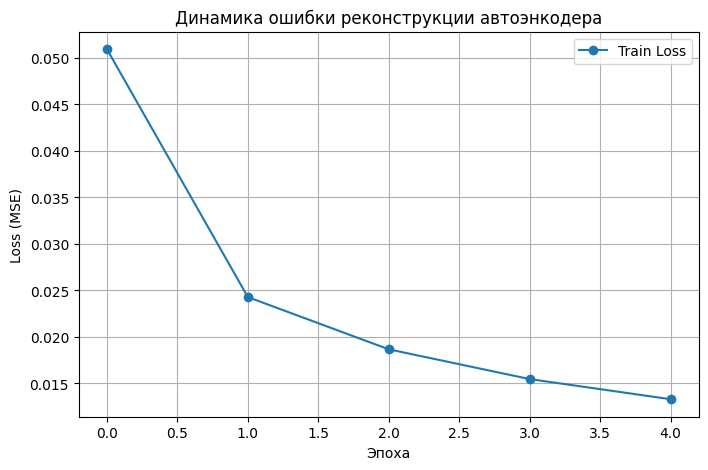

In [7]:
# Задача 3. Анализ динамики ошибки автоэнкодера

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.title('Динамика ошибки реконструкции автоэнкодера')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Проанализируйте график

**Интерпретация:**  
График показывает устойчивое снижение ошибки реконструкции по эпохам, значит автоэнкодер успешно обучается. Наиболее резкое уменьшение `MSE Loss` наблюдается в начале обучения, после чего кривая становится более пологой - это замедление прироста качества. Признаков роста ошибки или нестабильного поведения на данном графике не видно (можно судить об отсутствии переобучения).

## Задача 4. Визуализация латентного пространства автоэнкодера

### Постановка задачи

Обучить вариант автоэнкодера с двумерным латентным пространством и
визуализировать распределение латентных векторов для тестовой выборки,
окрашивая точки по истинным классам цифр.


[2D AE] Эпоха 1/3, loss = 0.0592
[2D AE] Эпоха 2/3, loss = 0.0462
[2D AE] Эпоха 3/3, loss = 0.0434


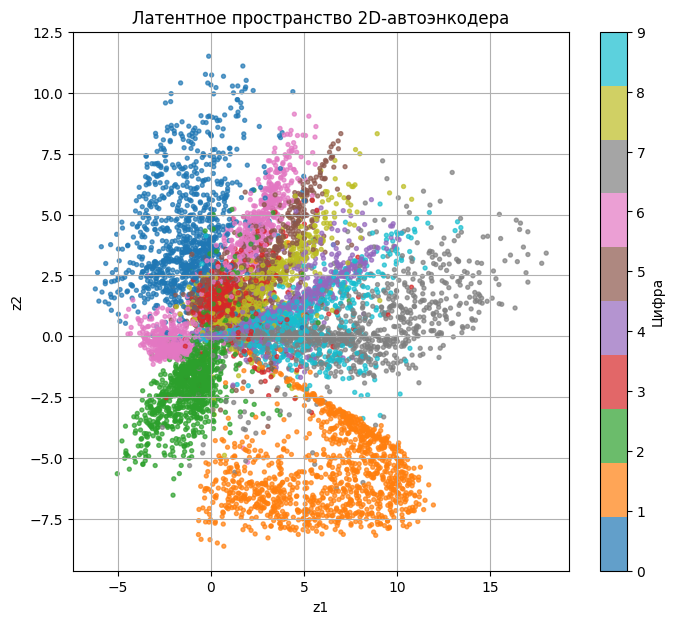

In [8]:
# Задача 4. Визуализация латентного пространства автоэнкодера

# возьмем тут class SimpleAutoencoder из задания 2, чтобы не перегружать код
# для этого заменим AutoencoderLatent2D -> SimpleAutoencoder
# ae_2d = AutoencoderLatent2D(latent_dim=2)

ae_2d = SimpleAutoencoder(latent_dim=2)

# loss и optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_2d.parameters(), lr=1e-3)

num_epochs_2d = 3 # для соответствия шаблону

# обучение
for epoch in range(num_epochs_2d):
    ae_2d.train()
    epoch_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        reconstructions = ae_2d(images)
        loss = criterion(reconstructions, images)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    print(f"[2D AE] Эпоха {epoch + 1}/{num_epochs_2d}, loss = {epoch_loss:.4f}")

ae_2d.eval()
latents = []
labels_list = []

with torch.no_grad():
     for images, labels in test_loader:
         images = images.to(device)

         z = ae_2d.encoder(images.view(images.size(0), -1))
         latents.append(z.cpu())
         labels_list.append(labels.cpu())


latents = torch.cat(latents, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()


plt.figure(figsize=(8, 7))
plt.scatter(latents[:, 0], latents[:, 1], c=labels_list, cmap='tab10', s=8, alpha=0.7)
plt.colorbar(label='Цифра')
plt.title('Латентное пространство 2D-автоэнкодера')
plt.xlabel('z1')
plt.ylabel('z2')
plt.grid(True)
plt.show()

**Интерпретация:**  
Для визуализации латентного пространства отдельный класс `AutoencoderLatent2D` не понадобился, так как архитектура `SimpleAutoencoder` уже изначально параметризована через `latent_dim`. Поэтому в этой задаче использовали ту же модель, изменив только размер латентного пространства на `2`, что методологически корректнее, потому что меняется только размер bottleneck, а не сама архитектура сети. Это полезно для сравнения.

По scatter plot видно, что автоэнкодер организует данные в двумерном латентном пространстве не случайно - для ряда цифр наблюдаются выраженные области концентрации точек. При этом разделение классов неполное. На графике заметна существенная область перекрытия нескольких цифр в центральной части. Это нормально, поскольку автоэнкодер обучался без целевой классификационной функции и оптимизировал только качество реконструкции. Латентное пространство отражает сходство изображений по их форме и контурам, а не стремится к идеальному разделению классов.

---

## Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

### Постановка задачи

Реализовать вариационный автоэнкодер со схожей архитектурой энкодера и декодера,
как у автоэнкодера, и обучить его на тех же данных.

- Энкодер VAE предсказывает среднее и разброс распределения в латентном пространстве.
- В латентном слое мы семплируем случайный вектор на основе этих параметров.
- Функция потерь VAE сочетает ошибку реконструкции и регуляризацию латентного пространства.


[VAE] Эпоха 1/5, total=52.2379, rec=50.1793, kl=2.0586
[VAE] Эпоха 2/5, total=41.4656, rec=35.7996, kl=5.6660
[VAE] Эпоха 3/5, total=35.7617, rec=28.3208, kl=7.4410
[VAE] Эпоха 4/5, total=33.6547, rec=25.6255, kl=8.0292
[VAE] Эпоха 5/5, total=32.6743, rec=24.2959, kl=8.3784


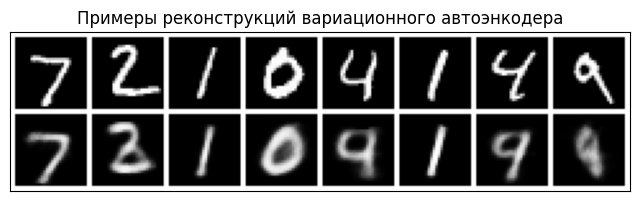

In [9]:
# Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
       
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def forward(self, x):
        
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon, mu, logvar


vae = VAE(latent_dim=32).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

num_epochs = 5

for epoch in range(num_epochs):
    vae.train()
    epoch_total = 0.0
    epoch_rec = 0.0
    epoch_kl = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar = vae(images)

        reconstruction_loss = F.mse_loss(
            x_recon, images, reduction='sum'
        ) / images.size(0)

        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp()
        ) / images.size(0)

        loss = reconstruction_loss + kl_loss

        loss.backward()
        optimizer.step()

        epoch_total += loss.item()
        epoch_rec += reconstruction_loss.item()
        epoch_kl += kl_loss.item()

    epoch_total /= len(train_loader)
    epoch_rec /= len(train_loader)
    epoch_kl /= len(train_loader)

    print(
        f"[VAE] Эпоха {epoch + 1}/{num_epochs}, "
        f"total={epoch_total:.4f}, rec={epoch_rec:.4f}, kl={epoch_kl:.4f}"
    )

# Визуализация реконструкций
vae.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)

    reconstructions, _, _ = vae(test_images)

    n_examples = 8
    originals = test_images[:n_examples].cpu()
    reconstructed = reconstructions[:n_examples].cpu()

    comparison = torch.cat([originals, reconstructed], dim=0)
    show_images(
        comparison,
        title="Примеры реконструкций вариационного автоэнкодера",
        nrow=n_examples
    )


**Интерпретация:**  
Как видно, суммарный `total loss` по эпохам уменьшается, а вместе с ним снижается и ошибка реконструкции `rec`. Это означает, что модель всё лучше минимизирует вариационную целевую функцию

$$
\mathcal{L}_{VAE} = \mathcal{L}_{rec} + \mathcal{L}_{KL},
$$

где $\mathcal{L}_{rec}$ отвечает за точность восстановления изображения, а $\mathcal{L}_{KL}$ — за приближение апостериорного распределения

$
q_\phi(z \mid x)
$
к априорному
$
p(z)=\mathcal{N}(0, I).
$

При этом `kl`-слагаемое возрастает, что и ожидается для VAE, так как модель не только улучшает реконструкцию, но и постепенно формирует более регулярное латентное пространство.

По визуализации видно, что реконструкции в целом сохраняют форму исходных цифр, однако получаются более размытыми и менее точными, чем у обычного автоэнкодера.

 VAE все таки решает более сложную задачу. Он ищет баланс между точной реконструкцией и вероятностной организацией скрытого пространства, а не минимизирует только ошибку восстановления.

## Задача 6. Сравнение реконструкций AE и VAE на одних и тех же примерах

### Постановка задачи

Построить визуальное сравнение реконструкций автоэнкодера и вариационного автоэнкодера
на одних и тех же изображениях.

- AE стремится максимально точно копировать вход.
- VAE может жертвовать точностью ради более гладкого латентного пространства.


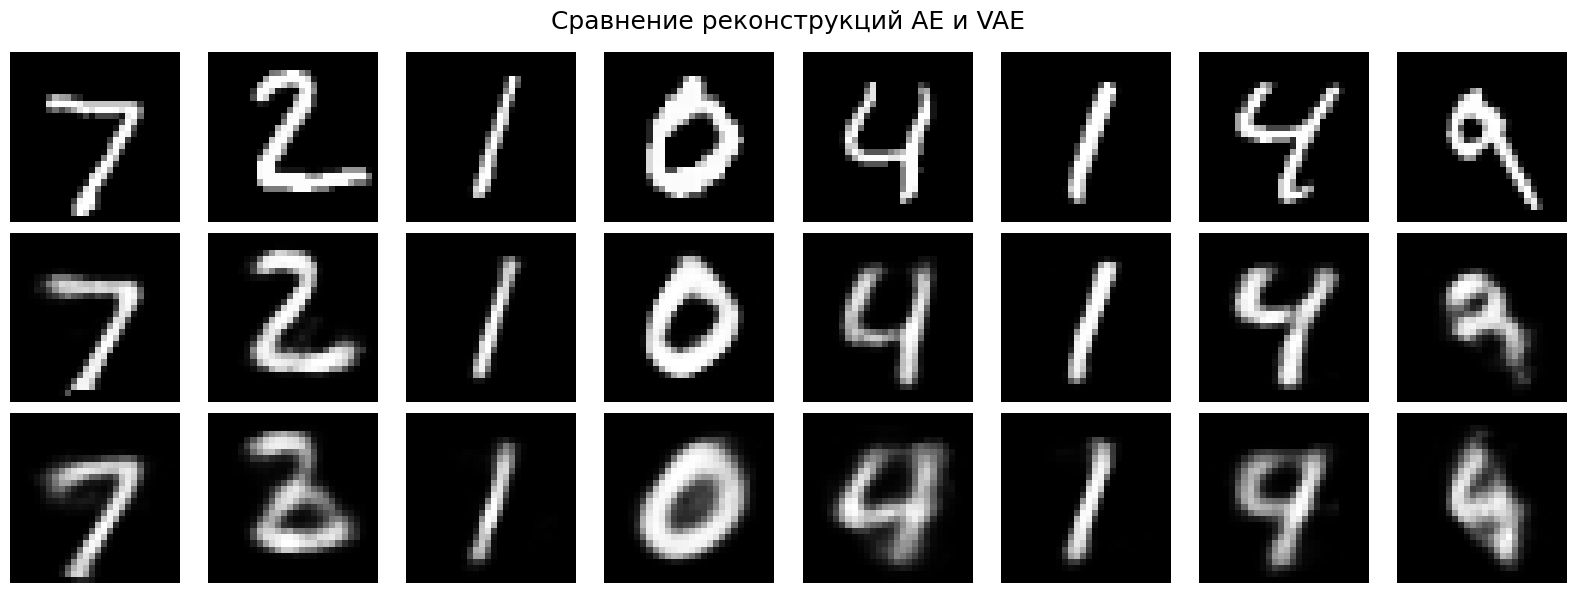

In [10]:
# Задача 6. Сравнение реконструкций AE и VAE

n = 8

model.eval()
vae.eval()

with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)

    ae_recon = model(test_images)
    vae_recon, _, _ = vae(test_images)

    originals = test_images[:n].cpu()
    ae_recon = ae_recon[:n].cpu()
    vae_recon = vae_recon[:n].cpu()

fig, axes = plt.subplots(3, n, figsize=(16, 6))

for i in range(n):
    # Строка 1: оригиналы
    axes[0, i].imshow(originals[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Строка 2: AE реконструкции
    axes[1, i].imshow(ae_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

    # Строка 3: VAE реконструкции
    axes[2, i].imshow(vae_recon[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

plt.suptitle('Сравнение реконструкций AE и VAE', fontsize=18)
plt.tight_layout()
plt.show()


**Интерпретация:**  
Сравнение показывает, что обычный автоэнкодер (вторая строка) восстанавливает изображения более резко и ближе к оригиналам, поскольку оптимизирует только ошибку реконструкции. Вариационный автоэнкодер (третья строка) даёт более размытые результаты и в некоторых случаях сильнее искажает форму цифры, так как его целевая функция включает не только реконструкционный член, но и регуляризацию латентного пространства.


Поэтому очевидно что часть точности реконструкции жертвуется ради более гладкой и вероятностно организованной структуры латентного пространства. На данном примере это  даже видно - AE лучше сохраняет детали контуров (с учетом всех особенностей почерка), а VAE строит более сглаженные, но менее точные реконструкции.

## Задача 7. Интерполяция в латентном пространстве VAE

### Постановка задачи

Взять два разных изображения из тестовой выборки, получить их латентные коды в VAE
и построить интерполяцию между ними. Визуализировать, как плавно меняется картинка
при движении по отрезку в латентном пространстве.


- В хорошо устроенном латентном пространстве небольшие изменения латентного кода
  приводят к плавным и осмысленным изменениям сгенерированного объекта.


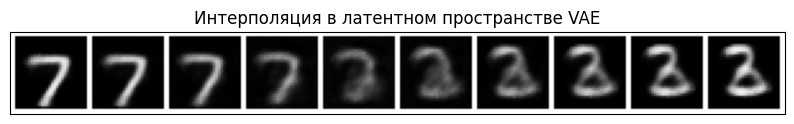

In [11]:
# Задача 7. Интерполяция в латентном пространстве VAE

# добавим метод decode в класс VAE
def decode(self, z):
    x_recon = self.decoder(z)
    x_recon = x_recon.view(-1, 1, 28, 28)
    return x_recon

VAE.decode = decode

idx1, idx2 = 0, 1
img1, _ = test_dataset[idx1]
img2, _ = test_dataset[idx2]

img1 = img1.to(device)
img2 = img2.to(device)

vae.eval()
with torch.no_grad():
    mu1, _ = vae.encode(img1.view(1, -1))
    mu2, _ = vae.encode(img2.view(1, -1))

alphas = torch.linspace(0, 1, steps=10).to(device)
interpolations = []

with torch.no_grad():
    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        x_interp = vae.decode(z_interp)
        interpolations.append(x_interp.cpu())

interpolations = torch.cat(interpolations, dim=0)

# визуализация
show_images(interpolations, title="Интерполяция в латентном пространстве VAE", nrow=10)


**Интерпретация:**  
Интерполяция показывает, что при движении по отрезку между двумя латентными кодами VAE изображение меняется постепенно. Начальная цифра `7` плавно трансформируется в цифру `3`. В промежуточных точках возникают размытые и смешанные формы, что абсолютно нормальнол для движения через области латентного пространства, соответствующие переходу между разными классами.

Такой результат подтверждает, что латентное пространство VAE организовано достаточно гладко, именно поэтому близкие латентные точки порождают визуально близкие объекты, а линейная интерполяция между кодами приводит к осмысленному "отображению" изображений.

---

## Задача 8. Генерация новых примеров из латентного пространства

### Постановка задачи

Сгенерировать набор новых изображений, не встречавшихся в обучающей выборке,
используя:

- выборку латентных векторов из простого распределения;
- декодер VAE для получения изображений.

Сравнить разнообразие и правдоподобие полученных картинок.


- В VAE латентное пространство подгоняется под стандартное нормальное распределение.
- Это позволяет генерировать новые данные, просто выбирая случайные точки в латентном пространстве.


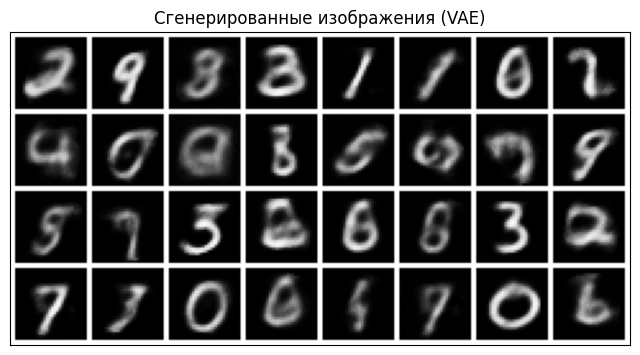

In [12]:
# Задача 8. Генерация новых примеров из латентного пространства

latent_dim = vae.fc_mu.out_features # возьмем из обученной модели
z_samples = torch.randn(32, latent_dim).to(device) # 32 изображения посмотрим

vae.eval()
with torch.no_grad():
    generated = vae.decoder(z_samples)
    generated = generated.view(-1, 1, 28, 28).cpu()

show_images(generated, title="Сгенерированные изображения (VAE)", nrow=8)


**Интерпретация:**  
Сэмплирование случайных векторов $z \sim \mathcal{N}(0, I)$ и их декодирование через VAE приводит к генерации новых изображений, не совпадающих с конкретными объектами обучающей выборки, но визуально похожих на рукописные цифры MNIST. Это подтверждает, что латентное пространство было согласовано с нормальным априорным распределением, и декодер способен преобразовывать типичные точки этого пространства в правдоподобные изображения.

По полученной сетке видно, что модель генерирует достаточно разнообразные цифры разных классов, однако качество генерации конечно оставляет желать лучшего. Часть изображений остаётся размытой, а некоторые цифры имеют неоднозначную форму. Это конечно непосредственно связано с типом обученного VAE (очевидно есть поле для донастройки) и выбранными параметрами.

## Задача 9. Количественное сравнение AE и VAE

### Постановка задачи

Сравнить автоэнкодер и вариационный автоэнкодер по двум простым метрикам:

1. Средняя ошибка реконструкции на тестовой выборке.
2. Простая оценка разнообразия сгенерированных примеров.


- Ошибка реконструкции показывает, насколько модель хорошо запоминает и восстанавливает обучающую выборку.
- Разнообразие семплов показывает, насколько модель способна порождать много разных примеров.


In [13]:
# Задача 9. Количественное сравнение AE и VAE

model.eval()
vae.eval()

ae_mse_sum = 0.0
vae_mse_sum = 0.0
n_batches = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        ae_recon = model(images)
        vae_recon, _, _ = vae(images)

        ae_mse_sum += F.mse_loss(ae_recon, images, reduction='mean').item()
        vae_mse_sum += F.mse_loss(vae_recon, images, reduction='mean').item()
        n_batches += 1

ae_mse = ae_mse_sum / n_batches
vae_mse = vae_mse_sum / n_batches

print(f"Средняя MSE реконструкции (AE):  {ae_mse:.6f}")
print(f"Средняя MSE реконструкции (VAE): {vae_mse:.6f}")


# для AE сэмплируем случайные z из латентного пространства и декодируем
# для VAE аналогично сэмплируем z ~ N(0, I) и декодируем

def mean_pairwise_distance(samples: torch.Tensor) -> float:
    """
    Возвращает среднюю попарную евклидову дистанцию
    """
    distances = torch.cdist(samples, samples, p=2)
    n = distances.size(0)

    # берём только верхний треугольник без диагонали
    i_upper = torch.triu_indices(n, n, offset=1)
    mean_dist = distances[i_upper[0], i_upper[1]].mean().item()
    return mean_dist


n_samples = 100
latent_dim = vae.fc_mu.out_features  # аналогично берем из прошлых заданий

with torch.no_grad():
    # AE samples
    z_ae = torch.randn(n_samples, latent_dim).to(device)
    ae_generated = model.decoder(z_ae).view(n_samples, -1).cpu()

    # VAE samples
    z_vae = torch.randn(n_samples, latent_dim).to(device)
    vae_generated = vae.decoder(z_vae).view(n_samples, -1).cpu()

diversity_ae = mean_pairwise_distance(ae_generated)
diversity_vae = mean_pairwise_distance(vae_generated)

print(f"Средняя попарная дистанция между сэмплами (AE):  {diversity_ae:.6f}")
print(f"Средняя попарная дистанция между сэмплами (VAE): {diversity_vae:.6f}")


Средняя MSE реконструкции (AE):  0.012378
Средняя MSE реконструкции (VAE): 0.029834
Средняя попарная дистанция между сэмплами (AE):  3.618362
Средняя попарная дистанция между сэмплами (VAE): 6.982393


**Интерпретация:**  
Сравнение подтверждает уже сделанные ранее наблюдения. Обычный автоэнкодер показывает меньшую ошибку реконструкции, то есть лучше восстанавливает исходные изображения.

Вариационный автоэнкодер напротив реконструирует менее точно, но демонстрирует более высокое разнообразие при генерации новых примеров. VAE оптимизирует не только реконструкцию, но и член регуляризации,
который делает латентное пространство более гладким и пригодным для сэмплирования из простого априорного распределения.

Следовательно, AE оказывается лучше в задаче точного восстановления уже известных данных, тогда как VAE выигрывает в способности порождать более разнообразные новые объекты. Или же иначе, AE сильнее как модель реконструкции, а VAE как модель генерации.


---

## Интерпретация результатов

- Обычный автоэнкодер хорошо восстанавливает входные изображения и дает низкую ошибку реконструкции,
  но его латентное пространство не имеет явной вероятностной структуры.
- Вариационный автоэнкодер вводит вероятностное латентное пространство и использует ELBO,
  чтобы одновременно учиться восстанавливать данные и упорядочивать скрытые представления.
- В визуальных сравнениях автоэнкодер дает более резкие реконструкции, тогда как VAE иногда сглаживает детали,
  но зато позволяет лучше интерполировать между объектами и легко генерировать новые примеры.
- Латентное пространство VAE оказывается более регулярным: интерполяции между точками выглядят плавно и осмысленно.
- При генерации из prior VAE естественным образом порождает правдоподобные объекты, в то время как AE
  при случайном выборе латентных векторов может выдавать менее реалистичные изображения.


## Выводы

1. Автоэнкодер — надежный инструмент для сжатия и реконструкции, но не полноценная вероятностная модель.
2. Вариационный автоэнкодер добавляет вероятностный слой и ELBO, что превращает его в генеративную модель,
   пригодную для порождения новых данных.
3. При сравнении на одной задаче AE выигрывает по точности реконструкции, но VAE выигрывает по структуре
   латентного пространства и возможностям генерации.
4. Выбор между AE и VAE зависит от цели: если важна точная реконструкция — используем AE; если нужны генерация
   и контролируемое латентное пространство — выбираем VAE.
5. На практике часто комбинируют идеи AE, VAE, GAN и диффузионных моделей, чтобы достичь баланса между
   качеством, стабильностью и выразительностью.
